#### Importing necessary packages and class

In [1]:
import sys
import pickle
sys.path.append('../analysis')
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
from collections import deque
from MBN_Res_Constrn import MBN_RC
from ClusterTracking import SCTA

#### Creating object of class MBN_RC

In [2]:
mbn=MBN_RC()

/home/jupyter-nimish/srg-tes-epilepsy-models/analysis/Mouse brain network/MouseBrainLib/mb_communities.npz already exists
DataUtils initialized


#### Loading Local Order data file

In [3]:
df = pd.read_pickle(r'../../data/Raw/FN/lo_fn.bz2',compression='bz2')
# reset index values as it is a multi-index dataframe
df_reset = df.reset_index()
# reset outer index values i.e iteration numbers
itr=df_reset['level_0'].drop_duplicates()
# itr_val contains iteration numbers which had transitions
itr_val=itr.values


#### Run scta for a particular set of local order 

In [4]:
itr_val[0:4]

array([ 5,  8,  9, 11])

In [5]:
#just put transition number (get this from itr_val) in df.loc[]

df_dum=df.loc[9].T
local_order=df_dum.values
scta = SCTA(mbn.binary_conn, 
            local_order, 
            local_order_phase = None, 
            sync_thrsh=0.3)
scta.track_clusters()
scta.update_synchronization_cluster_stats()
whole_toe=list(scta.TIME_OF_ENTRY)
left_toe=list(scta.TIME_OF_ENTRY[0:213])
right_toe=list(scta.TIME_OF_ENTRY[213:426])


Cluster tracking complete!


#### Plot scta for above

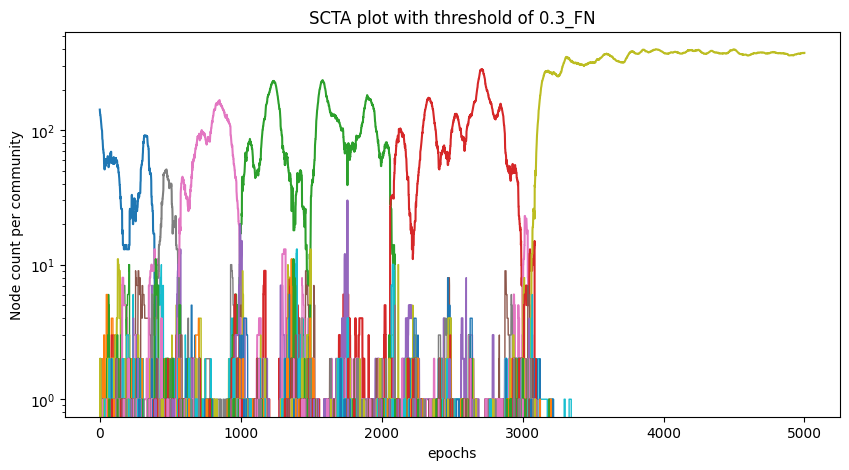

In [8]:
f1 = plt.figure(figsize=(10, 5))
for i in range(scta.MIN_CLUSTER_ID, scta.MAX_CLUSTER_ID):
    if np.max(scta.count_per_sync_cluster[:,i]) > 10:
        plt.plot(np.linspace(0, scta.window_size-1, scta.window_size), 
                 scta.count_per_sync_cluster[:,i], label=""+str(i))
    else:
        plt.plot(np.linspace(0, scta.window_size-1, scta.window_size), 
                 scta.count_per_sync_cluster[:,i], linewidth=1)

plt.xlabel("epochs")
plt.ylabel("Node count per community")
plt.yscale("log")
plt.title('SCTA plot with threshold of 0.3_FN')
plt.savefig('SCTA_3.png')


#### Making colormap


In [17]:
matrix=scta.node_communities

In [18]:
unique_values, counts = np.unique(matrix, return_counts=True)

In [24]:
idx=np.argsort(counts)[-3:]

In [25]:
top_3_value = unique_values[idx]

In [26]:
top_3_counts = counts[idx]

In [28]:
# Create a DataFrame to display the top 3 values and their counts
top_3_df = pd.DataFrame({'Value': top_3_value, 'Count': top_3_counts})

print(top_3_df)


   Value    Count
0   43.0   106213
1   59.0   670912
2    0.0  1164002


In [29]:
np.place(matrix,matrix==0,np.nan)

In [64]:

desired_order = [item for sublist in _x.values() for item in sublist]
rearranged_matrix = matrix[:, desired_order]

In [66]:
rearranged_matrix = matrix[:, desired_order]


In [63]:
matrix.shape

(5000, 426)

In [72]:
_x[0][-1]

371

In [75]:
matrix

array([[ 1., nan, nan, ..., nan, nan, nan],
       [ 1., nan, nan, ..., nan, nan, nan],
       [ 1., nan, nan, ..., nan, nan, nan],
       ...,
       [59., 59., 59., ..., nan, nan, 59.],
       [59., 59., 59., ..., nan, nan, 59.],
       [59., 59., 59., ..., nan, nan, 59.]])

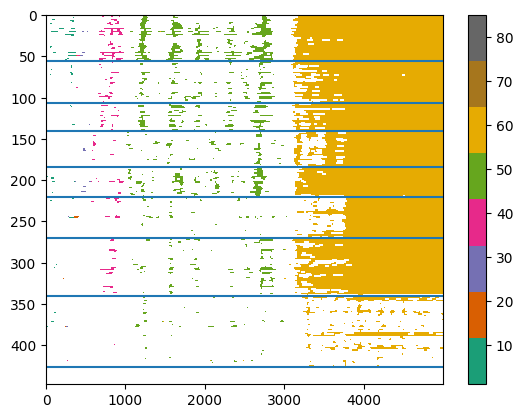

In [76]:
plt.imshow(rearranged_matrix.T,cmap='Dark2',aspect='auto')
for _i in np.cumsum([len(v) for v in _x.values()]): 
    plt.axhline(_i)
colorbar=plt.colorbar()

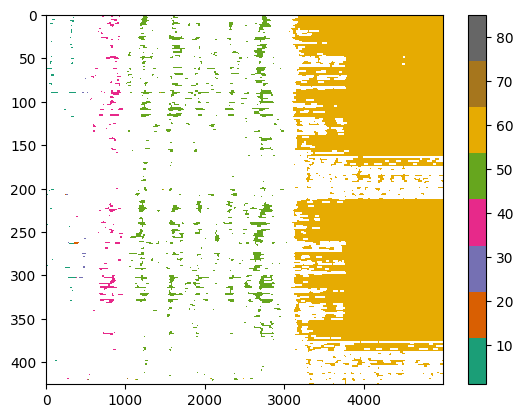

In [32]:
plt.imshow(matrix.T,cmap='Dark2',aspect='auto')
colorbar=plt.colorbar()

In [61]:
type(_x[0])

list

#### Run SCTA for a set of local orders automatically
Store time of entry  
Store node_communities data

In [5]:
left_toe=[]
right_toe=[]
whole_toe=[]
# df_nc to store node communities data
df_nc=pd.DataFrame()
tr_count=0
count=0
# put range of indices for how many transitions you need to do scta
for x in itr_val[0:4]:
    df_dum=df.loc[x].T
    if df_dum.shape[1]/426==1:
        tr_count+=1
        local_order=df_dum.values
        scta = SCTA(mbn.binary_conn, 
            local_order, 
            local_order_phase = None, 
            sync_thrsh=0.3)
        scta.track_clusters()
        scta.update_synchronization_cluster_stats()
        left_toe.append(list(scta.TIME_OF_ENTRY[0:213]))
        right_toe.append(list(scta.TIME_OF_ENTRY[213:426]))
        whole_toe.append(list(scta.TIME_OF_ENTRY))
        df_ncdum=pd.DataFrame(scta.node_communities)
        
        #creating multi-index dataframe
        index=[[tr_count]*5000,list(range(0,5000))]
        df_ncdum=df_ncdum.set_index(index)
        df_nc = pd.concat([df_nc,df_ncdum])
        print(f'{tr_count} Cluster track complete for transition {x}')
    else:
        
        f_limit=426
        df_dum=df_dum.T
        #i is count of number of transitions
        i=df_dum.shape[0]/426
        while count<i:
            tr_count+=1
            df_ext=df_dum.iloc[0+(f_limit*count):426+(f_limit*count)]
            df_ext=df_ext.T
            local_order=df_ext.values
            scta = SCTA(mbn.binary_conn, 
            local_order, 
            local_order_phase = None, 
            sync_thrsh=0.3)
            scta.track_clusters()
            scta.update_synchronization_cluster_stats()
            left_toe.append(list(scta.TIME_OF_ENTRY[0:213]))
            right_toe.append(list(scta.TIME_OF_ENTRY[213:426]))
            whole_toe.append(list(scta.TIME_OF_ENTRY))
            df_ncdum=pd.DataFrame(scta.node_communities)
        
            #creating multi-index dataframe
            index=[[tr_count]*5000,list(range(0,5000))]
            df_ncdum=df_ncdum.set_index(index)
            df_nc = pd.concat([df_nc,df_ncdum])
            
            
            print(f'{tr_count} Cluster track complete for transition {x}')
            
            count+=1
    
    
            
            
l_toe_df=pd.DataFrame(left_toe)
r_toe_df=pd.DataFrame(right_toe)
whole_toe_df = pd.DataFrame(whole_toe)
whole_toe_df.to_pickle('toe_orb_4.bz2',compression='bz2')
df_nc.to_pickle('nc_fn_4.bz2',compression='bz2')    

Cluster tracking complete!
1 Cluster track complete for transition 5
Cluster tracking complete!
2 Cluster track complete for transition 5
Cluster tracking complete!
3 Cluster track complete for transition 8
Cluster tracking complete!
4 Cluster track complete for transition 9
Cluster tracking complete!
5 Cluster track complete for transition 11


In [ ]:
df_nc.info()

In [ ]:
df_nc.loc[1]

In [ ]:
df_nc.loc[2]

In [ ]:
df_nc.loc[3]

#### Plotting TOE to compare  
1. Average time of entry of Node of Interest (NOI) in the main cluster for the full network
2. Average time of entry for all nodes in the full network vs dropout network (remember, we hypothesized that when some node is removed, it might make it harder for another region that it is connected to to become part of the sync cluster...)

#### Nodes of interest

1. Peri: 36
2. ENTI: 53
3. ORB: 23
4. RE: 113
5. BLA: 64
6. PIR: 43

In [17]:

df1  = pd.read_pickle(r'../../data/Raw/check_20/toe_fn_20.bz2',compression='bz2')
df2  = pd.read_pickle(r'../../data/Raw/check_20/toe_peri_20.bz2',compression='bz2')
df3  = pd.read_pickle(r'../../data/Raw/check_20/toe_enti_20.bz2',compression='bz2')
df4  = pd.read_pickle(r'../../data/Raw/check_20/toe_bla_20.bz2',compression='bz2')
df5  = pd.read_pickle(r'../../data/Raw/check_20/toe_orb_20.bz2',compression='bz2')
df6  = pd.read_pickle(r'../../data/Raw/check_20/toe_pir_20.bz2',compression='bz2')
df7 = pd.read_pickle(r'../../data/Raw/check_20/toe_re_20.bz2',compression='bz2')

#### Finding mean TOE for all node for a particular kind of network

In [18]:
#FULL NETWORK
fn_mean=[]
fn_median=[]
for i in list(range(0,426)):
    fn_mean.append(df1[i].mean())
    fn_median.append(df1[i].median()) 

In [19]:
#PERI NETWORK
peri_mean=[]
peri_median=[]
for i in list(range(0,426)):
    peri_mean.append(df2[i].mean())
    peri_median.append(df2[i].median())

In [20]:
#ENTI NETWORK
enti_mean=[]
enti_median=[]
for i in list(range(0,426)):
    enti_mean.append(df3[i].mean())
    enti_median.append(df3[i].median()) 

In [21]:
#BLA NETWORK
bla_mean=[]
bla_median=[]
for i in list(range(0,426)):
    bla_mean.append(df4[i].mean())
    bla_median.append(df4[i].median()) 

In [22]:
#ORB NETWORK
orb_mean=[]
orb_median=[]
for i in list(range(0,426)):
    orb_mean.append(df5[i].mean())
    orb_median.append(df5[i].median()) 

In [23]:
#PIR NETWORK
pir_mean=[]
pir_median=[]
for i in list(range(0,426)):
    pir_mean.append(df6[i].mean())
    pir_median.append(df6[i].median())  

In [24]:
#RE NETWORK
re_mean=[]
re_median=[]
for i in list(range(0,426)):
    re_mean.append(df7[i].mean())
    re_median.append(df7[i].median()) 

#### Load MB communities data file



In [25]:

with open('../Mouse brain network/MouseBrainLib/mb_communities_dict.pickle', 'rb') as f:
    _x = pickle.load(f)

In [26]:
_x.keys()


dict_keys([0, 2, 3, 4, 6, 7, 1, 5])

#### Creating data according to mb communities above

In [27]:
[len(v) for v in _x.values()]

[56, 50, 34, 44, 36, 50, 70, 86]

In [28]:
#FULL NETWORK
#### Creating data according to node cluster
fn_orbital=[]
fn_motor=[]
fn_visual=[]
fn_olfa=[]
fn_hthal=[]
fn_hcampus=[]
fn_midbrain=[]
fn_hindbrain=[]
mean=fn_mean
for i in _x[3]:
    fn_orbital.append(mean[i])

for i in _x[0]:
    fn_motor.append(mean[i])

for i in _x[2]:
    fn_visual.append(mean[i])

for i in _x[6]:
    fn_olfa.append(mean[i])

for i in _x[4]:
    fn_hthal.append(mean[i])

for i in _x[7]:
    fn_hcampus.append(mean[i])

for i in _x[1]:
    fn_midbrain.append(mean[i])

for i in _x[5]:
    fn_hindbrain.append(mean[i])

In [29]:
#PERI NETWORK
peri_orbital=[]
peri_motor=[]
peri_visual=[]
peri_olfa=[]
peri_hthal=[]
peri_hcampus=[]
peri_midbrain=[]
peri_hindbrain=[]
mean=peri_mean
for i in _x[3]:
    peri_orbital.append(mean[i])

for i in _x[0]:
   peri_motor.append(mean[i])

for i in _x[2]:
    peri_visual.append(mean[i])

for i in _x[6]:
    peri_olfa.append(mean[i])

for i in _x[4]:
    peri_hthal.append(mean[i])

for i in _x[7]:
    peri_hcampus.append(mean[i])

for i in _x[1]:
    peri_midbrain.append(mean[i])

for i in _x[5]:
    peri_hindbrain.append(mean[i])

In [30]:
#ENTI NETWORK
#### Creating data according to node cluster
enti_orbital=[]
enti_motor=[]
enti_visual=[]
enti_olfa=[]
enti_hthal=[]
enti_hcampus=[]
enti_midbrain=[]
enti_hindbrain=[]
mean=enti_mean
for i in _x[3]:
    enti_orbital.append(mean[i])

for i in _x[0]:
   enti_motor.append(mean[i])

for i in _x[2]:
    enti_visual.append(mean[i])

for i in _x[6]:
    enti_olfa.append(mean[i])

for i in _x[4]:
    enti_hthal.append(mean[i])

for i in _x[7]:
    enti_hcampus.append(mean[i])

for i in _x[1]:
    enti_midbrain.append(mean[i])

for i in _x[5]:
    enti_hindbrain.append(mean[i])

In [31]:
#BLA NETWORK
bla_orbital=[]
bla_motor=[]
bla_visual=[]
bla_olfa=[]
bla_hthal=[]
bla_hcampus=[]
bla_midbrain=[]
bla_hindbrain=[]
mean=bla_mean
for i in _x[3]:
    bla_orbital.append(mean[i])

for i in _x[0]:
   bla_motor.append(mean[i])

for i in _x[2]:
    bla_visual.append(mean[i])

for i in _x[6]:
    bla_olfa.append(mean[i])

for i in _x[4]:
    bla_hthal.append(mean[i])

for i in _x[7]:
    bla_hcampus.append(mean[i])

for i in _x[1]:
    bla_midbrain.append(mean[i])

for i in _x[5]:
    bla_hindbrain.append(mean[i])

In [32]:
#BLA NETWORK
orb_orbital=[]
orb_motor=[]
orb_visual=[]
orb_olfa=[]
orb_hthal=[]
orb_hcampus=[]
orb_midbrain=[]
orb_hindbrain=[]
mean=orb_mean
for i in _x[3]:
    orb_orbital.append(mean[i])

for i in _x[0]:
   orb_motor.append(mean[i])

for i in _x[2]:
    orb_visual.append(mean[i])

for i in _x[6]:
    orb_olfa.append(mean[i])

for i in _x[4]:
    orb_hthal.append(mean[i])

for i in _x[7]:
    orb_hcampus.append(mean[i])

for i in _x[1]:
    orb_midbrain.append(mean[i])

for i in _x[5]:
    orb_hindbrain.append(mean[i])

In [33]:
#PIR NETWORK
#### Creating data according to node cluster
pir_orbital=[]
pir_motor=[]
pir_visual=[]
pir_olfa=[]
pir_hthal=[]
pir_hcampus=[]
pir_midbrain=[]
pir_hindbrain=[]
mean=pir_mean
for i in _x[3]:
    pir_orbital.append(mean[i])

for i in _x[0]:
   pir_motor.append(mean[i])

for i in _x[2]:
    pir_visual.append(mean[i])

for i in _x[6]:
    pir_olfa.append(mean[i])

for i in _x[4]:
    pir_hthal.append(mean[i])

for i in _x[7]:
    pir_hcampus.append(mean[i])

for i in _x[1]:
    pir_midbrain.append(mean[i])

for i in _x[5]:
    pir_hindbrain.append(mean[i])

In [34]:
#RE NETWORK
re_orbital=[]
re_motor=[]
re_visual=[]
re_olfa=[]
re_hthal=[]
re_hcampus=[]
re_midbrain=[]
re_hindbrain=[]
mean=re_mean
for i in _x[0]:
    re_orbital.append(mean[i])

for i in _x[2]:
   re_motor.append(mean[i])

for i in _x[3]:
    re_visual.append(mean[i])

for i in _x[4]:
    re_olfa.append(mean[i])

for i in _x[6]:
    re_hthal.append(mean[i])

for i in _x[7]:
    re_hcampus.append(mean[i])

for i in _x[1]:
    re_midbrain.append(mean[i])

for i in _x[5]:
    re_hindbrain.append(mean[i])

In [35]:
#BLA NETWORK
bla_orbital=[]
bla_motor=[]
bla_visual=[]
bla_olfa=[]
bla_hthal=[]
bla_hcampus=[]
bla_midbrain=[]
bla_hindbrain=[]
mean=re_mean
for i in _x[0]:
    bla_orbital.append(mean[i])

for i in _x[2]:
    bla_motor.append(mean[i])

for i in _x[3]:
    bla_visual.append(mean[i])

for i in _x[4]:
    bla_olfa.append(mean[i])

for i in _x[6]:
    bla_hthal.append(mean[i])

for i in _x[7]:
    bla_hcampus.append(mean[i])

for i in _x[1]:
    bla_midbrain.append(mean[i])

for i in _x[5]:
    bla_hindbrain.append(mean[i])

#### Plotting mean TOE of nodes different colors for each MB community

/tmp/ipykernel_1773450/3185846052.py:195: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels( interval_labels)


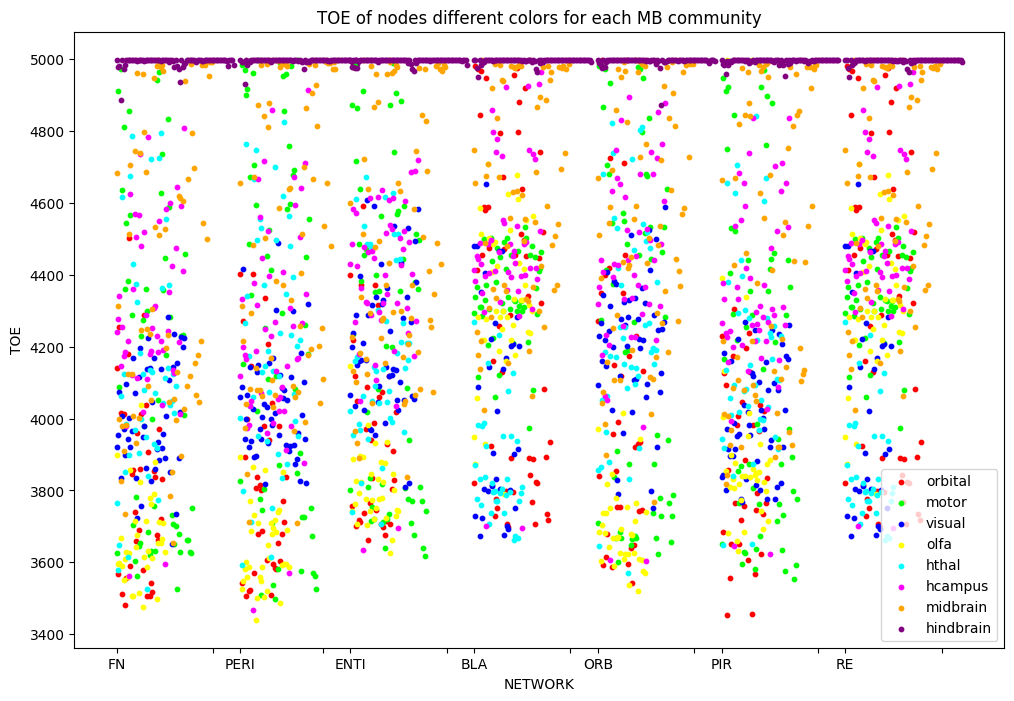

In [36]:
###### import matplotlib.pyplot as plt
import numpy as np

# Sample data
categories1 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data1 = {
    'orbital': fn_orbital,
    'motor': fn_motor,
    'visual': fn_visual,
    'olfa': fn_olfa, 
    'hthal': fn_hthal,
    'hcampus': fn_hcampus,
    'midbrain': fn_midbrain,
    'hindbrain': fn_hindbrain
}

categories2 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data2 = {
    'orbital': peri_orbital,
    'motor': peri_motor,
    'visual': peri_visual,
    'olfa': peri_olfa, 
    'hthal': peri_hthal,
    'hcampus': peri_hcampus,
    'midbrain': peri_midbrain,
    'hindbrain': peri_hindbrain
}

categories3 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data3 = {
    'orbital': enti_orbital,
    'motor': enti_motor,
    'visual': enti_visual,
    'olfa': enti_olfa, 
    'hthal': enti_hthal,
    'hcampus': enti_hcampus,
    'midbrain': enti_midbrain,
    'hindbrain': enti_hindbrain
}


categories4 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data4 = {
    'orbital': bla_orbital,
    'motor': bla_motor,
    'visual': bla_visual,
    'olfa': bla_olfa, 
    'hthal': bla_hthal,
    'hcampus': bla_hcampus,
    'midbrain': bla_midbrain,
    'hindbrain': bla_hindbrain
}

categories5 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data5 = {
    'orbital': orb_orbital,
    'motor': orb_motor,
    'visual': orb_visual,
    'olfa': orb_olfa, 
    'hthal': orb_hthal,
    'hcampus': orb_hcampus,
    'midbrain': orb_midbrain,
    'hindbrain': orb_hindbrain
}

categories6 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data6 = {
    'orbital': pir_orbital,
    'motor': pir_motor,
    'visual': pir_visual,
    'olfa': pir_olfa, 
    'hthal': pir_hthal,
    'hcampus': pir_hcampus,
    'midbrain': pir_midbrain,
    'hindbrain': pir_hindbrain
}


categories7 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data7 = {
    'orbital': re_orbital,
    'motor': re_motor,
    'visual': re_visual,
    'olfa': re_olfa, 
    'hthal': re_hthal,
    'hcampus': re_hcampus,
    'midbrain': re_midbrain,
    'hindbrain': re_hindbrain
}

#use this set of colors for paper
#colors = ["#00FFFF","#0000FF", "#ADD8E6", "#0000CD", "#808000", "#008000", "#006400", "#8B4513"]
#use this set of colors for more informative
colors = [ '#FF0000', '#00FF00',  '#0000FF',  '#FFFF00',  '#00FFFF', '#FF00FF', '#FFA500', '#800080' ]
#colors = [ '#FF0000', '#00FF00',  '#0000FF',  '#FFFF00',  '#00FFFF', '#FF00FF', '#FFA500', '#800080' ]
# Plotting
fig, ax = plt.subplots(figsize=(12,8))
for i,category in enumerate(categories1):
    y = data1[category]
    x = list(range(0,len(data1[category])))

     # Add jitter to x-values
    x_jittered = np.random.normal(x, 0.02, len(x))
    
    # Define sizes for scatter dots
    #sizes = np.random.uniform(0, 10, len(y))
    
    # Create scatter plot
    ax.scatter(x, y, s=10, color=colors[i % len(colors)], label=category)
    #x = np.random.normal(i + 1, 0.04, len(y))
    #ax.scatter(x,y, color=colors[i % len(colors)], label=category)
    #ax[0,1].scatter(x,y, color=colors[i % len(colors)], label=category)

for i,category in enumerate(categories2):
    y = data2[category]
    x = list(range(90,90+len(data2[category])))

     # Add jitter to x-values
    #x_jittered = np.random.normal(x, 0.02, len(x))
    
    # Define sizes for scatter dots
    #sizes = np.random.uniform(0, 10, len(y))
    
    # Create scatter plot
    ax.scatter(x, y, s=10, color=colors[i % len(colors)])

for i,category in enumerate(categories3):
    y = data3[category]
    x = list(range(170,170+len(data3[category])))

     # Add jitter to x-values
    #x_jittered = np.random.normal(x, 0.02, len(x))
    
    # Define sizes for scatter dots
    #sizes = np.random.uniform(0, 10, len(y))
    
    # Create scatter plot
    ax.scatter(x, y, s=10, color=colors[i % len(colors)])

for i,category in enumerate(categories4):
    y = data4[category]
    x = list(range(260,260+len(data4[category])))

     # Add jitter to x-values
    #x_jittered = np.random.normal(x, 0.02, len(x))
    
    # Define sizes for scatter dots
    #sizes = np.random.uniform(0, 10, len(y))
    
    # Create scatter plot
    ax.scatter(x, y, s=10, color=colors[i % len(colors)])


for i,category in enumerate(categories5):
    y = data5[category]
    x = list(range(350,350+len(data5[category])))

     # Add jitter to x-values
    #x_jittered = np.random.normal(x, 0.02, len(x))
    
    # Define sizes for scatter dots
    #sizes = np.random.uniform(0, 10, len(y))
    
    # Create scatter plot
    ax.scatter(x, y, s=10, color=colors[i % len(colors)])


for i,category in enumerate(categories6):
    y = data6[category]
    x = list(range(440,440+len(data6[category])))

     # Add jitter to x-values
    #x_jittered = np.random.normal(x, 0.02, len(x))
    
    # Define sizes for scatter dots
    #sizes = np.random.uniform(0, 10, len(y))
    
    # Create scatter plot
    ax.scatter(x, y, s=10, color=colors[i % len(colors)])

for i,category in enumerate(categories7):
    y = data7[category]
    x = list(range(530,530+len(data7[category])))

     # Add jitter to x-values
    #x_jittered = np.random.normal(x, 0.02, len(x))
    
    # Define sizes for scatter dots
    #sizes = np.random.uniform(0, 10, len(y))
    
    # Create scatter plot
    ax.scatter(x, y, s=10, color=colors[i % len(colors)])
custom_ticks = [0, 70,90,150,170,240,260,330,350,420,440,510,530,600]
interval_labels = [ 'FN', '', 'PERI', '', 'ENTI', '', 'BLA', '', 'ORB', '', 'PIR', '', 'RE']
ax.set_xticklabels( interval_labels)
ax.set_xticks(custom_ticks)
ax.set_ylabel('TOE')
ax.set_xlabel('NETWORK')
ax.legend()

# Add title for clarity
plt.title('TOE of nodes different colors for each MB community')

# Show the plot

plt.savefig('TOE_mb_comm_dc')

/tmp/ipykernel_1773450/769073576.py:195: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels( interval_labels)


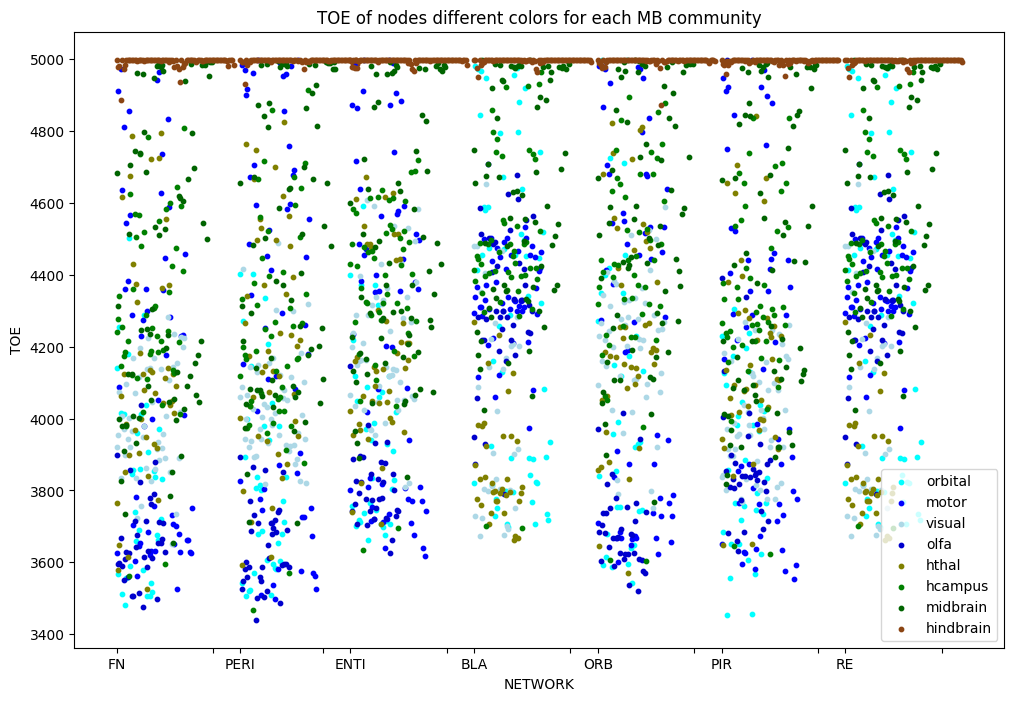

In [48]:
###### import matplotlib.pyplot as plt
import numpy as np

# Sample data
categories1 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data1 = {
    'orbital': fn_orbital,
    'motor': fn_motor,
    'visual': fn_visual,
    'olfa': fn_olfa, 
    'hthal': fn_hthal,
    'hcampus': fn_hcampus,
    'midbrain': fn_midbrain,
    'hindbrain': fn_hindbrain
}

categories2 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data2 = {
    'orbital': peri_orbital,
    'motor': peri_motor,
    'visual': peri_visual,
    'olfa': peri_olfa, 
    'hthal': peri_hthal,
    'hcampus': peri_hcampus,
    'midbrain': peri_midbrain,
    'hindbrain': peri_hindbrain
}

categories3 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data3 = {
    'orbital': enti_orbital,
    'motor': enti_motor,
    'visual': enti_visual,
    'olfa': enti_olfa, 
    'hthal': enti_hthal,
    'hcampus': enti_hcampus,
    'midbrain': enti_midbrain,
    'hindbrain': enti_hindbrain
}


categories4 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data4 = {
    'orbital': bla_orbital,
    'motor': bla_motor,
    'visual': bla_visual,
    'olfa': bla_olfa, 
    'hthal': bla_hthal,
    'hcampus': bla_hcampus,
    'midbrain': bla_midbrain,
    'hindbrain': bla_hindbrain
}

categories5 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data5 = {
    'orbital': orb_orbital,
    'motor': orb_motor,
    'visual': orb_visual,
    'olfa': orb_olfa, 
    'hthal': orb_hthal,
    'hcampus': orb_hcampus,
    'midbrain': orb_midbrain,
    'hindbrain': orb_hindbrain
}

categories6 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data6 = {
    'orbital': pir_orbital,
    'motor': pir_motor,
    'visual': pir_visual,
    'olfa': pir_olfa, 
    'hthal': pir_hthal,
    'hcampus': pir_hcampus,
    'midbrain': pir_midbrain,
    'hindbrain': pir_hindbrain
}


categories7 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data7 = {
    'orbital': re_orbital,
    'motor': re_motor,
    'visual': re_visual,
    'olfa': re_olfa, 
    'hthal': re_hthal,
    'hcampus': re_hcampus,
    'midbrain': re_midbrain,
    'hindbrain': re_hindbrain
}

#use this set of colors for paper
colors = ["#00FFFF","#0000FF", "#ADD8E6", "#0000CD", "#808000", "#008000", "#006400", "#8B4513"]
#use this set of colors for more informative
#colors = [ '#FF0000', '#00FF00',  '#0000FF',  '#FFFF00',  '#00FFFF', '#FF00FF', '#FFA500', '#800080' ]
#colors = [ '#FF0000', '#00FF00',  '#0000FF',  '#FFFF00',  '#00FFFF', '#FF00FF', '#FFA500', '#800080' ]
# Plotting
fig, ax = plt.subplots(figsize=(12,8))
for i,category in enumerate(categories1):
    y = data1[category]
    x = list(range(0,len(data1[category])))

     # Add jitter to x-values
    x_jittered = np.random.normal(x, 0.02, len(x))
    
    # Define sizes for scatter dots
    #sizes = np.random.uniform(0, 10, len(y))
    
    # Create scatter plot
    ax.scatter(x, y, s=10, color=colors[i % len(colors)], label=category)
    #x = np.random.normal(i + 1, 0.04, len(y))
    #ax.scatter(x,y, color=colors[i % len(colors)], label=category)
    #ax[0,1].scatter(x,y, color=colors[i % len(colors)], label=category)

for i,category in enumerate(categories2):
    y = data2[category]
    x = list(range(90,90+len(data2[category])))

     # Add jitter to x-values
    #x_jittered = np.random.normal(x, 0.02, len(x))
    
    # Define sizes for scatter dots
    #sizes = np.random.uniform(0, 10, len(y))
    
    # Create scatter plot
    ax.scatter(x, y, s=10, color=colors[i % len(colors)])

for i,category in enumerate(categories3):
    y = data3[category]
    x = list(range(170,170+len(data3[category])))

     # Add jitter to x-values
    #x_jittered = np.random.normal(x, 0.02, len(x))
    
    # Define sizes for scatter dots
    #sizes = np.random.uniform(0, 10, len(y))
    
    # Create scatter plot
    ax.scatter(x, y, s=10, color=colors[i % len(colors)])

for i,category in enumerate(categories4):
    y = data4[category]
    x = list(range(260,260+len(data4[category])))

     # Add jitter to x-values
    #x_jittered = np.random.normal(x, 0.02, len(x))
    
    # Define sizes for scatter dots
    #sizes = np.random.uniform(0, 10, len(y))
    
    # Create scatter plot
    ax.scatter(x, y, s=10, color=colors[i % len(colors)])


for i,category in enumerate(categories5):
    y = data5[category]
    x = list(range(350,350+len(data5[category])))

     # Add jitter to x-values
    #x_jittered = np.random.normal(x, 0.02, len(x))
    
    # Define sizes for scatter dots
    #sizes = np.random.uniform(0, 10, len(y))
    
    # Create scatter plot
    ax.scatter(x, y, s=10, color=colors[i % len(colors)])


for i,category in enumerate(categories6):
    y = data6[category]
    x = list(range(440,440+len(data6[category])))

     # Add jitter to x-values
    #x_jittered = np.random.normal(x, 0.02, len(x))
    
    # Define sizes for scatter dots
    #sizes = np.random.uniform(0, 10, len(y))
    
    # Create scatter plot
    ax.scatter(x, y, s=10, color=colors[i % len(colors)])

for i,category in enumerate(categories7):
    y = data7[category]
    x = list(range(530,530+len(data7[category])))

     # Add jitter to x-values
    #x_jittered = np.random.normal(x, 0.02, len(x))
    
    # Define sizes for scatter dots
    #sizes = np.random.uniform(0, 10, len(y))
    
    # Create scatter plot
    ax.scatter(x, y, s=10, color=colors[i % len(colors)])
custom_ticks = [0, 70,90,150,170,240,260,330,350,420,440,510,530,600]
interval_labels = [ 'FN', '', 'PERI', '', 'ENTI', '', 'BLA', '', 'ORB', '', 'PIR', '', 'RE']
ax.set_xticklabels( interval_labels)
ax.set_xticks(custom_ticks)
ax.set_ylabel('TOE')
ax.set_xlabel('NETWORK')
ax.legend()

# Add title for clarity
plt.title('TOE of nodes different colors for each MB community')

# Show the plot

plt.savefig('TOE_mb_comm_pc')

#### Boxplot of communities ToE for each network

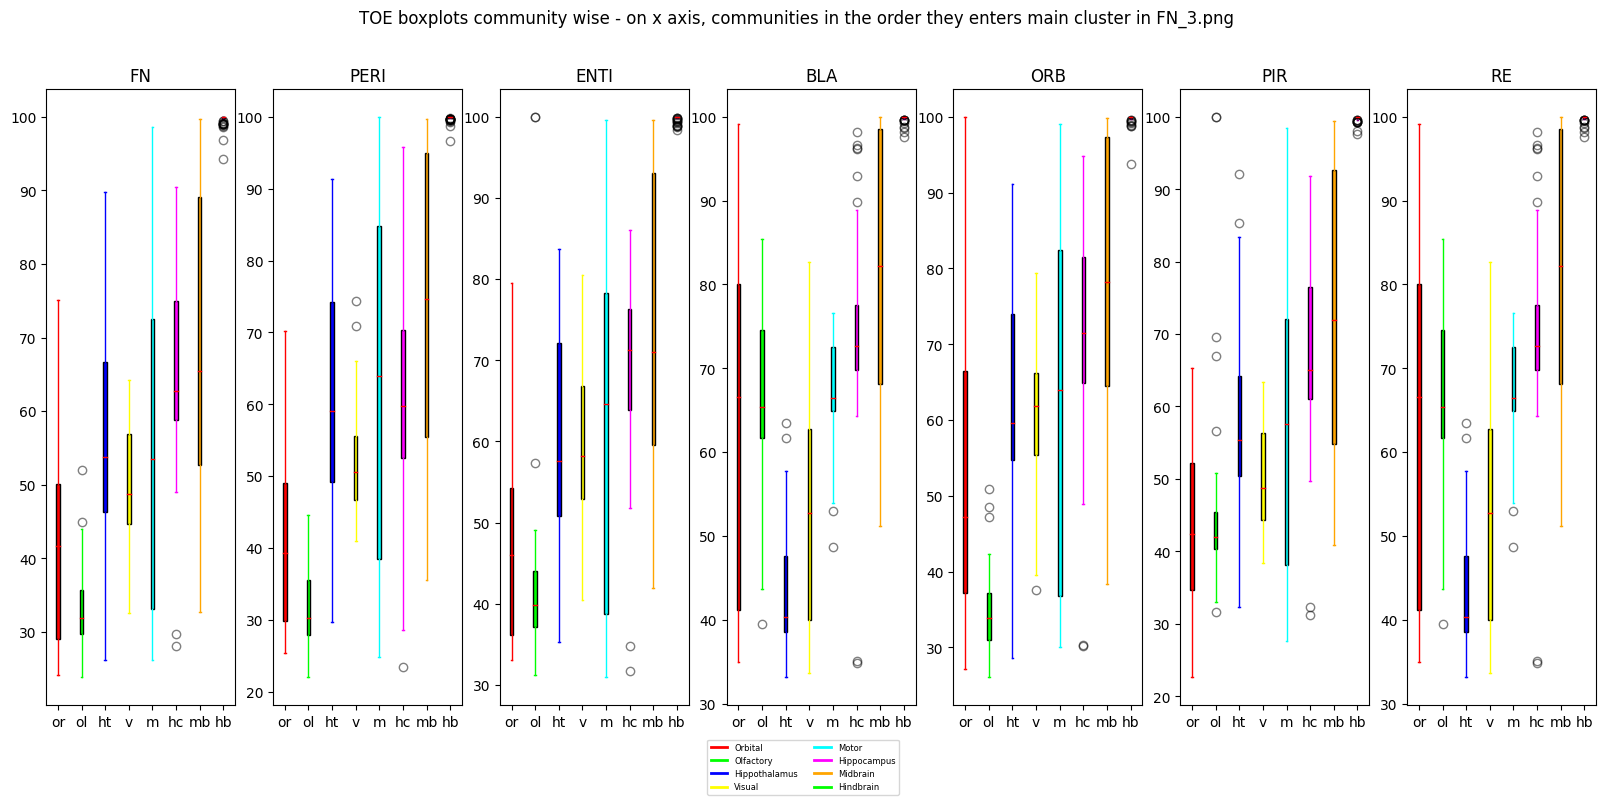

In [119]:
categories1 = ['orbital','olfa','hthal','visual','motor','hcampus','midbrain','hindbrain']
data1 = {
    'orbital': fn_orbital,
    'motor': fn_motor,
    'visual': fn_visual,
    'olfa': fn_olfa, 
    'hthal': fn_hthal,
    'hcampus': fn_hcampus,
    'midbrain': fn_midbrain,
    'hindbrain': fn_hindbrain
}

categories2 = ['orbital','olfa','hthal','visual','motor','hcampus','midbrain','hindbrain']
data2 = {
    'orbital': peri_orbital,
    'motor': peri_motor,
    'visual': peri_visual,
    'olfa': peri_olfa, 
    'hthal': peri_hthal,
    'hcampus': peri_hcampus,
    'midbrain': peri_midbrain,
    'hindbrain': peri_hindbrain
}

categories3 = ['orbital','olfa','hthal','visual','motor','hcampus','midbrain','hindbrain']
data3 = {
    'orbital': enti_orbital,
    'motor': enti_motor,
    'visual': enti_visual,
    'olfa': enti_olfa, 
    'hthal': enti_hthal,
    'hcampus': enti_hcampus,
    'midbrain': enti_midbrain,
    'hindbrain': enti_hindbrain
}


categories4 = ['orbital','olfa','hthal','visual','motor','hcampus','midbrain','hindbrain']
data4 = {
    'orbital': bla_orbital,
    'motor': bla_motor,
    'visual': bla_visual,
    'olfa': bla_olfa, 
    'hthal': bla_hthal,
    'hcampus': bla_hcampus,
    'midbrain': bla_midbrain,
    'hindbrain': bla_hindbrain
}

categories5 = ['orbital','olfa','hthal','visual','motor','hcampus','midbrain','hindbrain']
data5 = {
    'orbital': orb_orbital,
    'motor': orb_motor,
    'visual': orb_visual,
    'olfa': orb_olfa, 
    'hthal': orb_hthal,
    'hcampus': orb_hcampus,
    'midbrain': orb_midbrain,
    'hindbrain': orb_hindbrain
}

categories6 = ['orbital','olfa','hthal','visual','motor','hcampus','midbrain','hindbrain']
data6 = {
    'orbital': pir_orbital,
    'motor': pir_motor,
    'visual': pir_visual,
    'olfa': pir_olfa, 
    'hthal': pir_hthal,
    'hcampus': pir_hcampus,
    'midbrain': pir_midbrain,
    'hindbrain': pir_hindbrain
}


categories7 = ['orbital','olfa','hthal','visual','motor','hcampus','midbrain','hindbrain']
data7 = {
    'orbital': re_orbital,
    'motor': re_motor,
    'visual': re_visual,
    'olfa': re_olfa, 
    'hthal': re_hthal,
    'hcampus': re_hcampus,
    'midbrain': re_midbrain,
    'hindbrain': re_hindbrain
}
fig,ax = plt.subplots(1,7,figsize=(20,8))
#paper color
#colors = ["#00FFFF","#0000FF", "#ADD8E6", "#0000CD", "#808000", "#008000", "#006400", "#8B4513"]
#different color
colors = [ '#FF0000', '#00FF00',  '#0000FF',  '#FFFF00',  '#00FFFF', '#FF00FF', '#FFA500', '#800080' ]
labels=['or','ol','ht','v','m','hc','mb','hb']  
for i,category in enumerate(categories1):
    
    y = data1[category]
    y = [(v-3000)*0.05 for v in y ]
    box = ax[0].boxplot(y, positions=[i + 0.1], patch_artist=True)
    for patch in box['boxes']:
        patch.set_facecolor(colors[i])
        
    for whisker in box['whiskers']:
        whisker.set_color(colors[i])
        
    for cap in box['caps']:
        cap.set_color(colors[i])
        
    for median in box['medians']:
        median.set_color('red')  # Setting median color separately
        
    for flier in box['fliers']:
        flier.set(marker='o', color=colors[i], alpha=0.5)

#ax.set_xticks(range(1, len(categories1) + 1))
#ax.set_xticklabels(categories1)

ax[0].set_title('FN')
ax[0].set_xticklabels(labels)


for i,category in enumerate(categories2):
    y = data2[category]
    y = [(v-3000)*0.05 for v in y ]
    
    box = ax[1].boxplot(y, positions=[i + 0.1], patch_artist=True)
    for patch in box['boxes']:
        patch.set_facecolor(colors[i])
        
    for whisker in box['whiskers']:
        whisker.set_color(colors[i])
        
    for cap in box['caps']:
        cap.set_color(colors[i])
        
    for median in box['medians']:
        median.set_color('red')  # Setting median color separately
        
    for flier in box['fliers']:
        flier.set(marker='o', color=colors[i], alpha=0.5)
ax[1].set_title('PERI')
ax[1].set_xticklabels(labels)
#ax.set_xticks(range(1, len(categories1) + 1))

for i,category in enumerate(categories3):
    y = data3[category]
    y = [(v-3000)*0.05 for v in y ]
    box = ax[2].boxplot(y, positions=[i + 0.1], patch_artist=True)
    for patch in box['boxes']:
        patch.set_facecolor(colors[i])
        
    for whisker in box['whiskers']:
        whisker.set_color(colors[i])
        
    for cap in box['caps']:
        cap.set_color(colors[i])
        
    for median in box['medians']:
        median.set_color('red')  # Setting median color separately
        
    for flier in box['fliers']:
        flier.set(marker='o', color=colors[i], alpha=0.5)
ax[2].set_title('ENTI')
#ax.set_xticks(range(1, len(categories1) + 1))
ax[2].set_xticklabels(labels)
for i,category in enumerate(categories4):
    y = data4[category]
    y = [(v-3000)*0.05 for v in y ]
    box = ax[3].boxplot(y, positions=[i + 0.1], patch_artist=True)
    for patch in box['boxes']:
        patch.set_facecolor(colors[i])
        
    for whisker in box['whiskers']:
        whisker.set_color(colors[i])
        
    for cap in box['caps']:
        cap.set_color(colors[i])
        
    for median in box['medians']:
        median.set_color('red')  # Setting median color separately
        
    for flier in box['fliers']:
        flier.set(marker='o', color=colors[i], alpha=0.5)
ax[3].set_title('BLA')
#ax.set_xticks(range(1, len(categories1) + 1))
ax[3].set_xticklabels(labels)

for i,category in enumerate(categories5):
    y = data5[category]
    y = [(v-3000)*0.05 for v in y ]
    box = ax[4].boxplot(y, positions=[i+ 0.1], patch_artist=True)
    for patch in box['boxes']:
        patch.set_facecolor(colors[i])
        
    for whisker in box['whiskers']:
        whisker.set_color(colors[i])
        
    for cap in box['caps']:
        cap.set_color(colors[i])
        
    for median in box['medians']:
        median.set_color('red')  # Setting median color separately
        
    for flier in box['fliers']:
        flier.set(marker='o', color=colors[i], alpha=0.5)
ax[4].set_title('ORB')
#ax.set_xticks(range(1, len(categories1) + 1))
ax[4].set_xticklabels(labels)

for i,category in enumerate(categories6):
    y = data6[category]
    y = [(v-3000)*0.05 for v in y ]
    box = ax[5].boxplot(y, positions=[i + 0.1], patch_artist=True)
    for patch in box['boxes']:
        patch.set_facecolor(colors[i])
        
    for whisker in box['whiskers']:
        whisker.set_color(colors[i])
        
    for cap in box['caps']:
        cap.set_color(colors[i])
        
    for median in box['medians']:
        median.set_color('red')  # Setting median color separately
        
    for flier in box['fliers']:
        flier.set(marker='o', color=colors[i], alpha=0.5)
ax[5].set_title('PIR')
ax[5].set_xticklabels(labels)
#ax.set_xticks(range(1, len(categories1) + 1))

for i,category in enumerate(categories7):
    
    y = data7[category]
    y = [(v-3000)*0.05 for v in y ]
    box = ax[6].boxplot(y, positions=[i+ 0.1], patch_artist=True)
    
    for patch in box['boxes']:
        patch.set_facecolor(colors[i])
        
    for whisker in box['whiskers']:
        whisker.set_color(colors[i])
        
    for cap in box['caps']:
        cap.set_color(colors[i])
        
    for median in box['medians']:
        median.set_color('red')  # Setting median color separately
        
    for flier in box['fliers']:
        flier.set(marker='o', color=colors[i], alpha=0.5)
ax[6].set_title('RE')


ax[6].set_xticklabels(labels)


fig.suptitle('TOE boxplots community wise - on x axis, communities in the order they enters main cluster in FN_3.png')

legend_elements = [Line2D([0], [0], color=colors[0], lw=2, label='Orbital'),
                   Line2D([0], [0], color=colors[1], lw=2, label='Olfactory'),
                   Line2D([0], [0], color=colors[2], lw=2, label='Hippothalamus'),
                   Line2D([0], [0], color=colors[3], lw=2, label='Visual'),
                   Line2D([0], [0], color=colors[4], lw=2, label='Motor'),
                   Line2D([0], [0], color=colors[5], lw=2, label='Hippocampus'),
                   Line2D([0], [0], color=colors[6], lw=2, label='Midbrain'),
                   Line2D([0], [0], color=colors[1], lw=2, label='Hindbrain'),
                   
                   
                  ]

# Add the super legend to the figure
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=6)
plt.savefig('TOE_boxplot_dcf.png')

#### Plotting only mean TOE per community for a particular network

In [63]:
#FULL NETWORK

d_mean=[]
for i in _x[3]:
    d_mean.append(df1[i].mean())
    orb_mean_fn=sum(d_mean)/len(d_mean)

for i in _x[0]:
    d_mean.append(df1[i].mean())
    motor_mean_fn=sum(d_mean)/len(d_mean)

for i in _x[2]:
    d_mean.append(df1[i].mean())
    vis_mean_fn=sum(d_mean)/len(d_mean)

for i in _x[6]:
    d_mean.append(df1[i].mean())
    olfa_mean_fn=sum(d_mean)/len(d_mean)

for i in _x[4]:
    d_mean.append(df1[i].mean())
    hthal_mean_fn=sum(d_mean)/len(d_mean)

for i in _x[7]:
    d_mean.append(df1[i].mean())
    hcampus_mean_fn=sum(d_mean)/len(d_mean)

for i in _x[1]:
    d_mean.append(df1[i].mean())
    midbrain_mean_fn=sum(d_mean)/len(d_mean)

for i in _x[5]:
    d_mean.append(df1[i].mean())
    hindbrain_mean_fn=sum(d_mean)/len(d_mean)

In [64]:
# PERI NETWORK

d_mean=[]
for i in _x[3]:
    d_mean.append(df2[i].mean())
    orb_mean_peri=sum(d_mean)/len(d_mean)

for i in _x[0]:
    d_mean.append(df2[i].mean())
    motor_mean_peri=sum(d_mean)/len(d_mean)

for i in _x[2]:
    d_mean.append(df2[i].mean())
    vis_mean_peri=sum(d_mean)/len(d_mean)

for i in _x[6]:
    d_mean.append(df2[i].mean())
    olfa_mean_peri=sum(d_mean)/len(d_mean)

for i in _x[4]:
    d_mean.append(df2[i].mean())
    hthal_mean_peri=sum(d_mean)/len(d_mean)

for i in _x[7]:
    d_mean.append(df2[i].mean())
    hcampus_mean_peri=sum(d_mean)/len(d_mean)

for i in _x[1]:
    d_mean.append(df2[i].mean())
    midbrain_mean_peri=sum(d_mean)/len(d_mean)

for i in _x[5]:
    d_mean.append(df2[i].mean())
    hindbrain_mean_peri=sum(d_mean)/len(d_mean)

In [65]:
#ENTI NETWORK

d_mean=[]
for i in _x[3]:
    d_mean.append(df3[i].mean())
    orb_mean_enti=sum(d_mean)/len(d_mean)

for i in _x[0]:
    d_mean.append(df3[i].mean())
    motor_mean_enti=sum(d_mean)/len(d_mean)

for i in _x[2]:
    d_mean.append(df3[i].mean())
    vis_mean_enti=sum(d_mean)/len(d_mean)

for i in _x[6]:
    d_mean.append(df3[i].mean())
    olfa_mean_enti=sum(d_mean)/len(d_mean)

for i in _x[4]:
    d_mean.append(df3[i].mean())
    hthal_mean_enti=sum(d_mean)/len(d_mean)

for i in _x[7]:
    d_mean.append(df3[i].mean())
    hcampus_mean_enti=sum(d_mean)/len(d_mean)

for i in _x[1]:
    d_mean.append(df3[i].mean())
    midbrain_mean_enti=sum(d_mean)/len(d_mean)

for i in _x[5]:
    d_mean.append(df3[i].mean())
    hindbrain_mean_enti=sum(d_mean)/len(d_mean)

In [66]:
#BLA NETWORK
d_mean=[]
for i in _x[3]:
    d_mean.append(df4[i].mean())
    orb_mean_bla=sum(d_mean)/len(d_mean)

for i in _x[0]:
    d_mean.append(df4[i].mean())
    motor_mean_bla=sum(d_mean)/len(d_mean)

for i in _x[2]:
    d_mean.append(df4[i].mean())
    vis_mean_bla=sum(d_mean)/len(d_mean)

for i in _x[6]:
    d_mean.append(df4[i].mean())
    olfa_mean_bla=sum(d_mean)/len(d_mean)

for i in _x[4]:
    d_mean.append(df4[i].mean())
    hthal_mean_bla=sum(d_mean)/len(d_mean)

for i in _x[7]:
    d_mean.append(df4[i].mean())
    hcampus_mean_bla=sum(d_mean)/len(d_mean)

for i in _x[1]:
    d_mean.append(df4[i].mean())
    midbrain_mean_bla=sum(d_mean)/len(d_mean)

for i in _x[5]:
    d_mean.append(df4[i].mean())
    hindbrain_mean_bla=sum(d_mean)/len(d_mean)

In [67]:
#ORB NETWORK

d_mean=[]
for i in _x[3]:
    d_mean.append(df5[i].mean())
    orb_mean_orb=sum(d_mean)/len(d_mean)

for i in _x[0]:
    d_mean.append(df5[i].mean())
    motor_mean_orb=sum(d_mean)/len(d_mean)

for i in _x[2]:
    d_mean.append(df5[i].mean())
    vis_mean_orb=sum(d_mean)/len(d_mean)

for i in _x[6]:
    d_mean.append(df5[i].mean())
    olfa_mean_orb=sum(d_mean)/len(d_mean)

for i in _x[4]:
    d_mean.append(df5[i].mean())
    hthal_mean_orb=sum(d_mean)/len(d_mean)

for i in _x[7]:
    d_mean.append(df5[i].mean())
    hcampus_mean_orb=sum(d_mean)/len(d_mean)

for i in _x[1]:
    d_mean.append(df5[i].mean())
    midbrain_mean_orb=sum(d_mean)/len(d_mean)

for i in _x[5]:
    d_mean.append(df5[i].mean())
    hindbrain_mean_orb=sum(d_mean)/len(d_mean)

In [68]:
#PIR NETWORK
d_mean=[]
for i in _x[3]:
    d_mean.append(df6[i].mean())
    orb_mean_pir=sum(d_mean)/len(d_mean)

for i in _x[0]:
    d_mean.append(df6[i].mean())
    motor_mean_pir=sum(d_mean)/len(d_mean)

for i in _x[2]:
    d_mean.append(df6[i].mean())
    vis_mean_pir=sum(d_mean)/len(d_mean)

for i in _x[6]:
    d_mean.append(df6[i].mean())
    olfa_mean_pir=sum(d_mean)/len(d_mean)

for i in _x[4]:
    d_mean.append(df6[i].mean())
    hthal_mean_pir=sum(d_mean)/len(d_mean)

for i in _x[7]:
    d_mean.append(df6[i].mean())
    hcampus_mean_pir=sum(d_mean)/len(d_mean)

for i in _x[1]:
    d_mean.append(df6[i].mean())
    midbrain_mean_pir=sum(d_mean)/len(d_mean)

for i in _x[5]:
    d_mean.append(df6[i].mean())
    hindbrain_mean_pir=sum(d_mean)/len(d_mean)

In [69]:
# RE NETWORK

d_mean=[]
for i in _x[3]:
    d_mean.append(df7[i].mean())
    orb_mean_re=sum(d_mean)/len(d_mean)

for i in _x[0]:
    d_mean.append(df7[i].mean())
    motor_mean_re=sum(d_mean)/len(d_mean)

for i in _x[2]:
    d_mean.append(df7[i].mean())
    vis_mean_re=sum(d_mean)/len(d_mean)

for i in _x[6]:
    d_mean.append(df7[i].mean())
    olfa_mean_re=sum(d_mean)/len(d_mean)

for i in _x[4]:
    d_mean.append(df7[i].mean())
    hthal_mean_re=sum(d_mean)/len(d_mean)

for i in _x[7]:
    d_mean.append(df7[i].mean())
    hcampus_mean_re=sum(d_mean)/len(d_mean)

for i in _x[1]:
    d_mean.append(df7[i].mean())
    midbrain_mean_re=sum(d_mean)/len(d_mean)

for i in _x[5]:
    d_mean.append(df7[i].mean())
    hindbrain_mean_re=sum(d_mean)/len(d_mean)

#### Plot of mean TOE of mb community for various networks

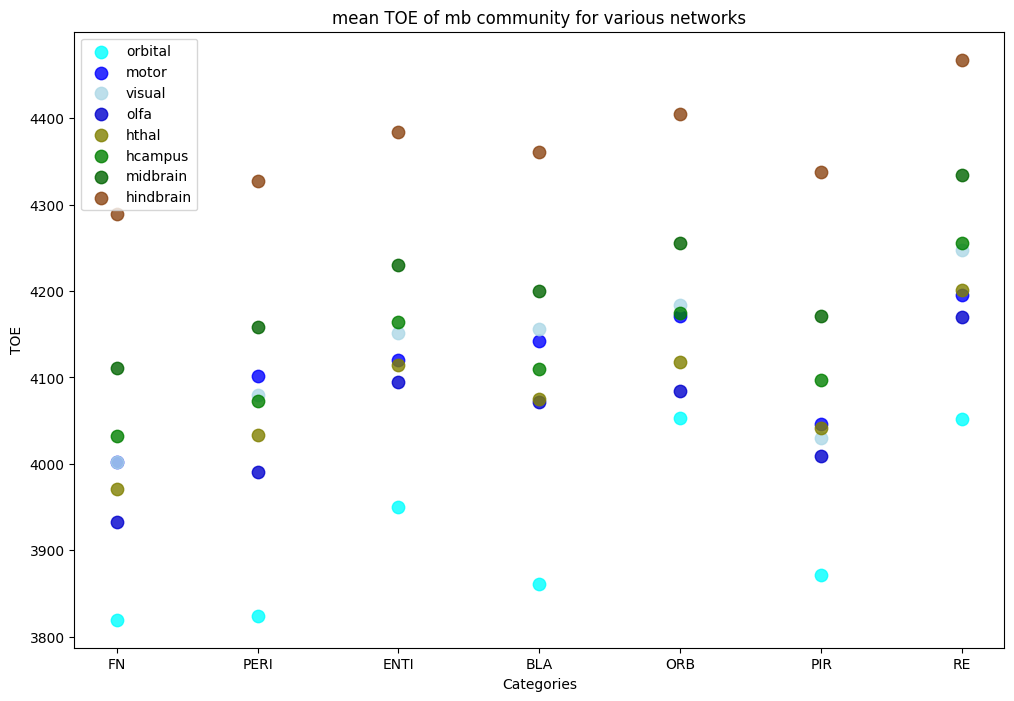

In [71]:
categories1 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data1 = {
    'orbital': orb_mean_fn,
    'motor': motor_mean_fn,
    'visual': vis_mean_fn,
    'olfa': olfa_mean_fn, 
    'hthal': hthal_mean_fn,
    'hcampus': hcampus_mean_fn,
    'midbrain': midbrain_mean_fn,
    'hindbrain': hindbrain_mean_fn
}

categories2 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data2 = {
    'orbital': orb_mean_peri,
    'motor': motor_mean_peri,
    'visual': vis_mean_peri,
    'olfa': olfa_mean_peri, 
    'hthal': hthal_mean_peri,
    'hcampus': hcampus_mean_peri,
    'midbrain': midbrain_mean_peri,
    'hindbrain': hindbrain_mean_peri
}

categories3 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data3 = {
    'orbital': orb_mean_enti,
    'motor': motor_mean_enti,
    'visual': vis_mean_enti,
    'olfa': olfa_mean_enti, 
    'hthal': hthal_mean_enti,
    'hcampus': hcampus_mean_enti,
    'midbrain': midbrain_mean_enti,
    'hindbrain': hindbrain_mean_enti
}

categories4 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data4 = {
    'orbital': orb_mean_bla,
    'motor': motor_mean_bla,
    'visual': vis_mean_bla,
    'olfa': olfa_mean_bla, 
    'hthal': hthal_mean_bla,
    'hcampus': hcampus_mean_bla,
    'midbrain': midbrain_mean_bla,
    'hindbrain': hindbrain_mean_bla
}


categories5 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data5 = {
    'orbital': orb_mean_orb,
    'motor': motor_mean_orb,
    'visual': vis_mean_orb,
    'olfa': olfa_mean_orb, 
    'hthal': hthal_mean_orb,
    'hcampus': hcampus_mean_orb,
    'midbrain': midbrain_mean_orb,
    'hindbrain': hindbrain_mean_orb
}


categories6 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data6 = {
    'orbital': orb_mean_pir,
    'motor': motor_mean_pir,
    'visual': vis_mean_pir,
    'olfa': olfa_mean_pir, 
    'hthal': hthal_mean_pir,
    'hcampus': hcampus_mean_pir,
    'midbrain': midbrain_mean_pir,
    'hindbrain': hindbrain_mean_pir
}


categories7 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data7 = {
    'orbital': orb_mean_re,
    'motor': motor_mean_re,
    'visual': vis_mean_re,
    'olfa': olfa_mean_re, 
    'hthal': hthal_mean_re,
    'hcampus': hcampus_mean_re,
    'midbrain': midbrain_mean_re,
    'hindbrain': hindbrain_mean_re
}

#colors = [ '#FF0000', '#00FF00',  '#0000FF',  '#FFFF00',  '#00FFFF', '#FF00FF', '#FFA500', '#800080' ]
colors = ["#00FFFF","#0000FF", "#ADD8E6", "#0000CD", "#808000", "#008000", "#006400", "#8B4513"]
# Plotting
fig, ax = plt.subplots(figsize=(12,8))
for i,category in enumerate(categories1):
    y = data1[category]
    x='FN'
    

     
    ax.scatter(x, y, s=80, color=colors[i % len(colors)], alpha=0.8,label=category)


for i,category in enumerate(categories2):
    y = data2[category]
    x='PERI'
    

     
    ax.scatter(x, y, s=80, color=colors[i % len(colors)], alpha=0.8)


for i,category in enumerate(categories3):
    y = data3[category]
    x='ENTI'
    

     
    ax.scatter(x, y, s=80, color=colors[i % len(colors)], alpha=0.8)


for i,category in enumerate(categories4):
    y = data4[category]
    x='BLA'
    

     
    ax.scatter(x, y, s=80, color=colors[i % len(colors)], alpha=0.8)


for i,category in enumerate(categories5):
    y = data5[category]
    x='ORB'
    

     
    ax.scatter(x, y, s=80, color=colors[i % len(colors)], alpha=0.8)


for i,category in enumerate(categories6):
    y = data6[category]
    x='PIR'
    

     
    ax.scatter(x, y, s=80, color=colors[i % len(colors)], alpha=0.8)

for i,category in enumerate(categories7):
    y = data7[category]
    x='RE'
    

     
    ax.scatter(x, y, s=80, color=colors[i % len(colors)], alpha=0.8)


custom_ticks=[0,1,2,3,4,5,6]
plt.title('mean TOE of mb community for various networks')
ax.set_xticks(custom_ticks)
ax.set_ylabel('TOE')
ax.set_xlabel('Categories')
ax.legend()
plt.savefig('TOE_mb_mean_pc.png')

In [80]:
hindbrain_mean_re - orb_mean_re 

415.5926539629895

In [81]:
hindbrain_mean_fn - orb_mean_fn

469.1514982049148

In [82]:
hindbrain_mean_bla - orb_mean_bla 

500.07872378446245

In [83]:
hindbrain_mean_orb - orb_mean_orb

352.0818420325877

In [84]:
hindbrain_mean_pir- orb_mean_pir

465.49361528649115

In [85]:
hindbrain_mean_peri - orb_mean_peri 

503.3676401546527

In [86]:
hindbrain_mean_enti - orb_mean_enti

434.59709893347053

#### Plot - mean TOE of mb community for various networks

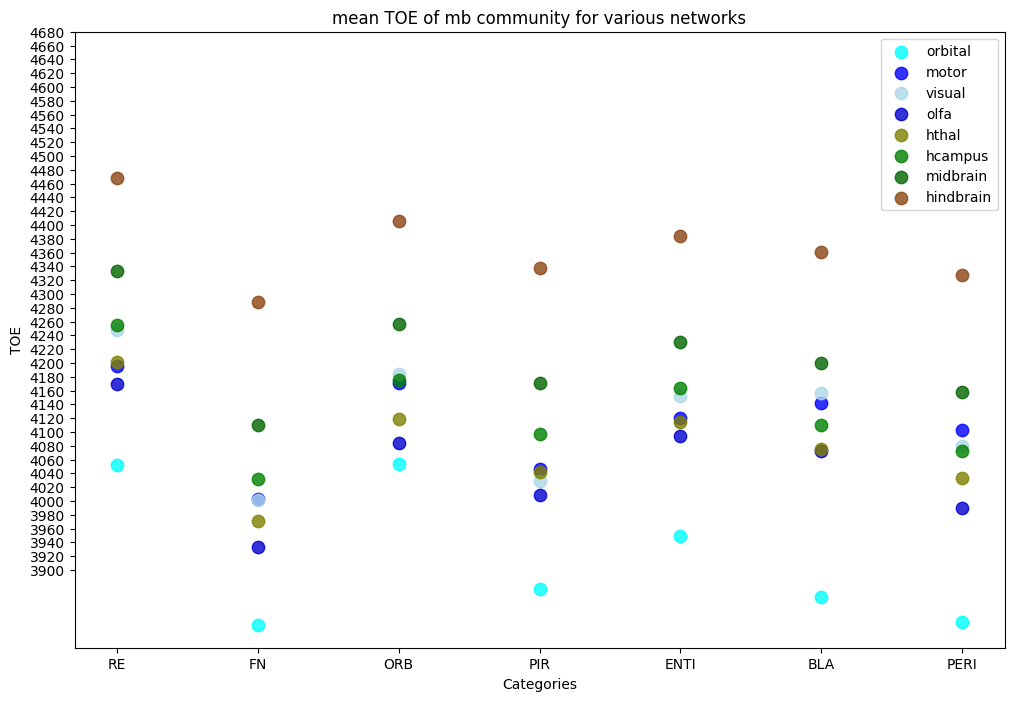

In [73]:
categories2 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data2 = {
    'orbital': orb_mean_fn,
    'motor': motor_mean_fn,
    'visual': vis_mean_fn,
    'olfa': olfa_mean_fn, 
    'hthal': hthal_mean_fn,
    'hcampus': hcampus_mean_fn,
    'midbrain': midbrain_mean_fn,
    'hindbrain': hindbrain_mean_fn
}

categories7 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data7 = {
    'orbital': orb_mean_peri,
    'motor': motor_mean_peri,
    'visual': vis_mean_peri,
    'olfa': olfa_mean_peri, 
    'hthal': hthal_mean_peri,
    'hcampus': hcampus_mean_peri,
    'midbrain': midbrain_mean_peri,
    'hindbrain': hindbrain_mean_peri
}

categories5 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data5 = {
    'orbital': orb_mean_enti,
    'motor': motor_mean_enti,
    'visual': vis_mean_enti,
    'olfa': olfa_mean_enti, 
    'hthal': hthal_mean_enti,
    'hcampus': hcampus_mean_enti,
    'midbrain': midbrain_mean_enti,
    'hindbrain': hindbrain_mean_enti
}

categories6 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data6 = {
    'orbital': orb_mean_bla,
    'motor': motor_mean_bla,
    'visual': vis_mean_bla,
    'olfa': olfa_mean_bla, 
    'hthal': hthal_mean_bla,
    'hcampus': hcampus_mean_bla,
    'midbrain': midbrain_mean_bla,
    'hindbrain': hindbrain_mean_bla
}


categories3 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data3 = {
    'orbital': orb_mean_orb,
    'motor': motor_mean_orb,
    'visual': vis_mean_orb,
    'olfa': olfa_mean_orb, 
    'hthal': hthal_mean_orb,
    'hcampus': hcampus_mean_orb,
    'midbrain': midbrain_mean_orb,
    'hindbrain': hindbrain_mean_orb
}


categories4 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data4 = {
    'orbital': orb_mean_pir,
    'motor': motor_mean_pir,
    'visual': vis_mean_pir,
    'olfa': olfa_mean_pir, 
    'hthal': hthal_mean_pir,
    'hcampus': hcampus_mean_pir,
    'midbrain': midbrain_mean_pir,
    'hindbrain': hindbrain_mean_pir
}


categories1 = ['orbital','motor','visual','olfa','hthal','hcampus','midbrain','hindbrain']
data1 = {
    'orbital': orb_mean_re,
    'motor': motor_mean_re,
    'visual': vis_mean_re,
    'olfa': olfa_mean_re, 
    'hthal': hthal_mean_re,
    'hcampus': hcampus_mean_re,
    'midbrain': midbrain_mean_re,
    'hindbrain': hindbrain_mean_re
}

#use this set of colors for paper
#colors = ["#00FFFF","#0000FF", "#ADD8E6", "#0000CD", "#808000", "#008000", "#006400", "#8B4513"]
#use this set of colors for paper
colors = ["#00FFFF","#0000FF", "#ADD8E6", "#0000CD", "#808000", "#008000", "#006400", "#8B4513"]
#colors = [ '#FF0000', '#00FF00',  '#0000FF',  '#FFFF00',  '#00FFFF', '#FF00FF', '#FFA500', '#800080' ]
# Plotting
fig, ax = plt.subplots(figsize=(12,8))
for i,category in enumerate(categories1):
    y = data1[category]
    x='RE'
    

     
    ax.scatter(x, y, s=80, color=colors[i % len(colors)], alpha=0.8,label=category)


for i,category in enumerate(categories2):
    y = data2[category]
    x='FN'
    

     
    ax.scatter(x, y, s=80, color=colors[i % len(colors)], alpha=0.8)


for i,category in enumerate(categories3):
    y = data3[category]
    x='ORB'
    

     
    ax.scatter(x, y, s=80, color=colors[i % len(colors)], alpha=0.8)


for i,category in enumerate(categories4):
    y = data4[category]
    x='PIR'
    

     
    ax.scatter(x, y, s=80, color=colors[i % len(colors)], alpha=0.8)


for i,category in enumerate(categories5):
    y = data5[category]
    x='ENTI'
    

     
    ax.scatter(x, y, s=80, color=colors[i % len(colors)], alpha=0.8)


for i,category in enumerate(categories6):
    y = data6[category]
    x='BLA'
    

     
    ax.scatter(x, y, s=80, color=colors[i % len(colors)], alpha=0.8)

for i,category in enumerate(categories7):
    y = data7[category]
    x='PERI'
    

     
    ax.scatter(x, y, s=80, color=colors[i % len(colors)], alpha=0.8)


custom_ticks_x=[0,1,2,3,4,5,6]
custom_ticks_y = list(range(3900,4700,20))
plt.title('mean TOE of mb community for various networks')
ax.set_xticks(custom_ticks_x)
ax.set_yticks(custom_ticks_y)
ax.set_ylabel('TOE')
ax.set_xlabel('Categories')
ax.legend()

#### Conclusions from above figure

Possible opinions:

Maybe the order in which the areas get synchronised is affecting transitions  

Maybe the time taken overall brain area to get synchronised

In [74]:
RE=[orb_mean_re,motor_mean_re,vis_mean_re,olfa_mean_re,hthal_mean_re,hcampus_mean_re,midbrain_mean_re,hindbrain_mean_re]
FN=[orb_mean_fn,motor_mean_fn,vis_mean_fn,olfa_mean_fn,hthal_mean_fn,hcampus_mean_fn,midbrain_mean_fn,hindbrain_mean_fn]
ORB=[orb_mean_orb,motor_mean_orb,vis_mean_orb,olfa_mean_orb,hthal_mean_orb,hcampus_mean_orb,midbrain_mean_orb,hindbrain_mean_orb]
PIR=[orb_mean_pir,motor_mean_pir,vis_mean_pir,olfa_mean_pir,hthal_mean_pir,hcampus_mean_pir,midbrain_mean_pir,hindbrain_mean_pir]
ENT=[orb_mean_enti,motor_mean_enti,vis_mean_enti,olfa_mean_enti,hthal_mean_enti,hcampus_mean_enti,midbrain_mean_enti,hindbrain_mean_enti]
BLA=[orb_mean_bla,motor_mean_bla,vis_mean_bla,olfa_mean_bla,hthal_mean_bla,hcampus_mean_bla,midbrain_mean_bla,hindbrain_mean_bla]
PERI=[orb_mean_peri,motor_mean_peri,vis_mean_peri,olfa_mean_peri,hthal_mean_peri,hcampus_mean_peri,midbrain_mean_peri,hindbrain_mean_peri]


In [75]:
key=['or','m','v','ol','ht','hc','mb','hb']
re_dict=dict(zip(key,RE))
fn_dict=dict(zip(key,FN))
orb_dict=dict(zip(key,ORB))
pir_dict=dict(zip(key,PIR))
ent_dict=dict(zip(key,ENT))
bla_dict=dict(zip(key,BLA))
peri_dict=dict(zip(key,PERI))

In [76]:
re_dict_s=dict(sorted(re_dict.items(),key=lambda item: item[1]))
fn_dict_s=dict(sorted(fn_dict.items(),key=lambda item: item[1]))
orb_dict_s=dict(sorted(orb_dict.items(),key=lambda item: item[1]))
pir_dict_s=dict(sorted(pir_dict.items(),key=lambda item: item[1]))
ent_dict_s=dict(sorted(ent_dict.items(),key=lambda item: item[1]))
bla_dict_s=dict(sorted(bla_dict.items(),key=lambda item: item[1]))
peri_dict_s=dict(sorted(peri_dict.items(),key=lambda item: item[1]))

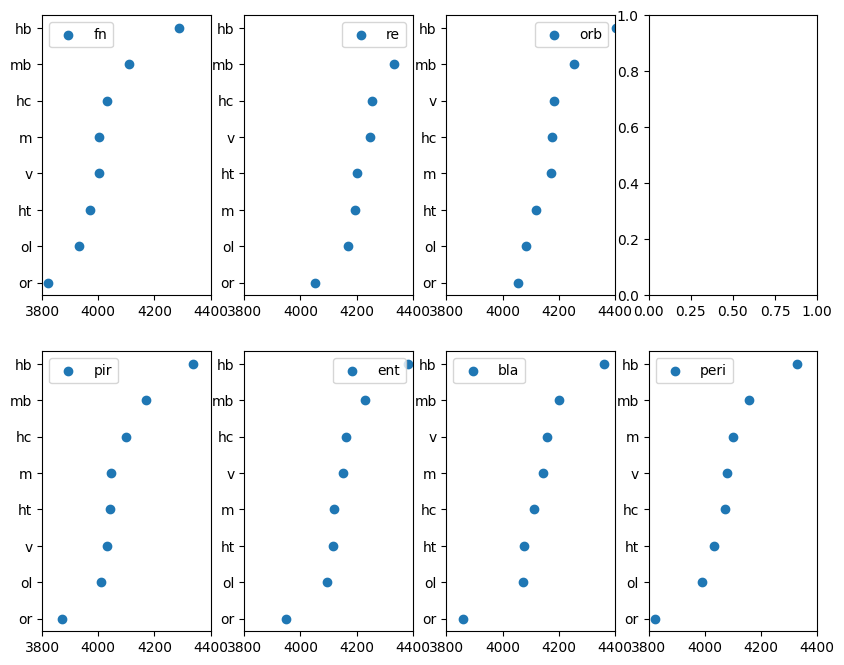

In [78]:
fig, axs = plt.subplots(2, 4, figsize=(10, 8))

axs[0, 0].scatter(fn_dict_s.values(),fn_dict_s.keys(),label='fn')
axs[0,0].set_xlim(3800,4400)
axs[0,0].legend()
axs[0,1].scatter(re_dict_s.values(),re_dict_s.keys(),label='re')
axs[0,1].set_xlim(3800,4400)
axs[0,1].legend()
axs[0,2].scatter(orb_dict_s.values(),orb_dict_s.keys(),label='orb')
axs[0,2].set_xlim(3800,4400)
axs[0,2].legend()
axs[1,0].scatter(pir_dict_s.values(),pir_dict_s.keys(),label='pir')
axs[1,0].set_xlim(3800,4400)
axs[1,0].legend()
axs[1,1].scatter(ent_dict_s.values(),ent_dict_s.keys(),label='ent')
axs[1,1].set_xlim(3800,4400)
axs[1,1].legend()
axs[1,2].scatter(bla_dict_s.values(),bla_dict_s.keys(),label='bla')
axs[1,2].set_xlim(3800,4400)
axs[1,2].legend()
axs[1,3].scatter(peri_dict_s.values(),peri_dict_s.keys(),label='peri')
axs[1,3].set_xlim(3800,4400)
axs[1,3].legend()

plt.savefig('time_seq.png')

#### Checking colormap


In [90]:
# reading data
df_nc = pd.read_pickle(r'../../data/Raw/check_20/nc_fn_20.bz2',compression='bz2')
df_nc.head()
df_toe=pd.read_pickle(r'../../data/Raw/check_20/toe_peri_20.bz2',compression='bz2')


In [53]:
df_nc.loc[3]

,0,1,2,3,4,5,6,7,8,9,...,416,417,418,419,420,421,422,423,424,425
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4996,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4997,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4998,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [262]:
df_toe.head()

,0,1,2,3,4,5,6,7,8,9,...,416,417,418,419,420,421,422,423,424,425
0,3294.0,4936.0,3647.0,4942.0,4999.0,4823.0,4646.0,4905.0,3651.0,4886.0,...,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0
1,3718.0,4999.0,4966.0,4999.0,4999.0,4999.0,4999.0,4999.0,4970.0,4999.0,...,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0
2,4828.0,4999.0,4819.0,4999.0,4999.0,4999.0,4999.0,4999.0,4832.0,4999.0,...,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0
3,3387.0,4916.0,4531.0,4999.0,4821.0,4887.0,4822.0,4826.0,4854.0,4999.0,...,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0
4,3372.0,4999.0,3448.0,4880.0,3565.0,4784.0,3453.0,4797.0,3535.0,4787.0,...,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0


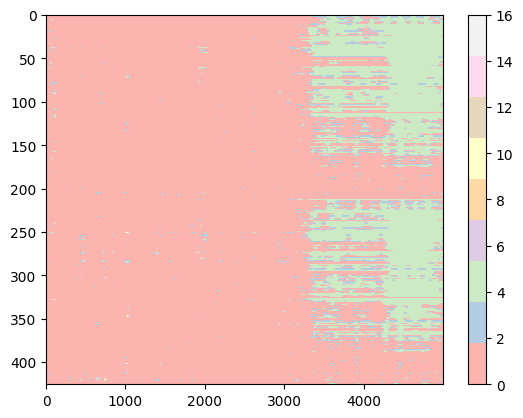

In [263]:
plt.imshow(a.T,cmap='Pastel1',aspect='auto')
colorbar=plt.colorbar()

In [275]:
a=df_nc.loc[2]

In [276]:
matrix=a.to_numpy()

In [277]:
np.unique(matrix)

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20.])

In [278]:
# Identify unique values in the matrix and their counts
unique_values, counts = np.unique(matrix, return_counts=True)

# Get the top 3 unique values based on their counts
top_3_indices = np.argsort(counts)[-3:]
top_3_values = unique_values[top_3_indices]
top_3_counts = counts[top_3_indices]

In [279]:
top_3_counts

array([  10199,  393637, 1713976])

In [280]:
top_3_values

array([2., 1., 0.])

In [281]:
top_3_values

array([2., 1., 0.])

In [282]:
# Create a mask to filter the matrix
filtered_matrix = np.where(np.isin(matrix, top_3_values), matrix, np.nan)


In [283]:
from matplotlib.colors import ListedColormap
# Define a list of colors for the top 3 values
colors = ['red', 'blue', 'green']

# Create a colormap from the list of colors
custom_cmap = ListedColormap(colors[:len(top_3_values)])


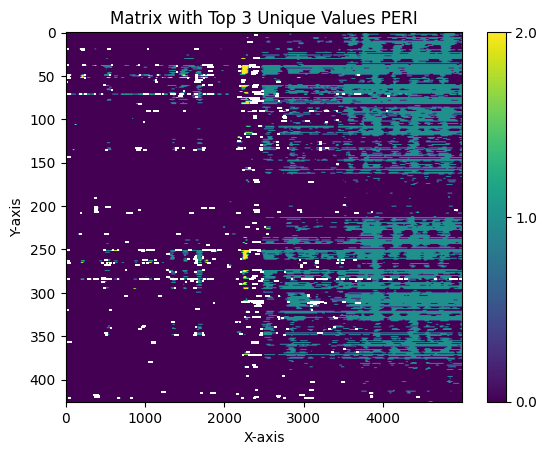

In [284]:
# Plot the filtered matrix with the custom colormap
plt.imshow(filtered_matrix.T, cmap='viridis', aspect='auto')
cbar = plt.colorbar(ticks=top_3_values)  # Add a colorbar with ticks for each top value
cbar.ax.set_yticklabels([str(val) for val in top_3_values])  # Set labels for the colorbar
plt.title('Matrix with Top 3 Unique Values PERI')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()


In [285]:
a.iloc[4000].unique()

array([1., 0., 2.])

In [ ]:
a.iloc[4000]

In [84]:
a.iloc[4800].value_counts()

1.0    276
0.0    150
Name: 4800, dtype: int64

(0.0, 5000.0)

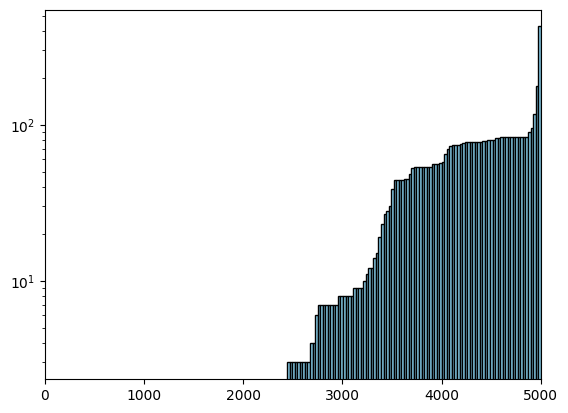

In [286]:
s_list=sorted(list(df_toe.iloc[1]))
plt.hist(s_list, bins=100, cumulative=True, color='skyblue', edgecolor='black')
plt.yscale('log')
plt.xlim(0, 5000)

In [120]:
df_itr=pd.read_pickle(r'../../data/Raw/FN/itr_data_fn.bz2')

In [121]:
df_loc=pd.read_pickle(r'../../data/Raw/FN/lo_fn.bz2')

In [122]:
# read 
df_reset = df_loc.reset_index()
# reset outer index values i.e iteration numbers
itr=df_reset['level_0'].drop_duplicates()
# itr_val contains iteration numbers which had transitions
itr_val=itr.values
itr_val[0:200]

array([  5,   8,   9,  11,  12,  14,  15,  16,  18,  19,  20,  22,  23,
        24,  25,  27,  30,  31,  33,  34,  35,  36,  37,  38,  40,  44,
        46,  47,  51,  52,  53,  54,  56,  57,  59,  61,  62,  63,  65,
        66,  71,  73,  75,  80,  81,  84,  85,  87,  94,  97,  98,  99,
       102, 103, 104, 108, 109, 110, 112, 114, 115, 119, 120, 122, 124,
       126, 127, 129, 130, 131, 132, 135, 136, 138, 139, 140, 142, 148,
       154, 156, 157, 158, 160, 161, 163, 164, 165, 167, 169, 170, 171,
       179, 181, 183, 189, 190, 191, 194, 195, 199, 200, 208, 209, 210,
       211, 212, 213, 215, 216, 217, 219, 221, 222, 229, 230, 232, 233,
       235, 237, 238, 239, 240, 242, 243, 246, 252, 253, 255, 259, 261,
       264, 266, 268, 270, 273, 274, 275, 276, 277, 280, 281, 284, 286,
       289, 290, 292, 294, 296, 297, 298, 300, 301, 303, 305, 306, 308,
       310, 311, 312, 313, 315, 317, 318, 325, 326, 331, 332, 333, 338,
       339, 341, 343, 344, 345, 346, 348, 350, 351, 352, 353, 35

In [123]:
df_nc = pd.read_pickle('../../data/Raw/check_20/nc_fn_20.bz2')


In [137]:
df_loc.head()

0         1         2         3         4         5         6     \
5 0  0.157077  0.160598  0.164243  0.167994  0.171832  0.175742  0.179711   
  1  0.014478  0.014080  0.013944  0.014074  0.014469  0.015114  0.015994   
  2  0.149793  0.147797  0.145818  0.143863  0.141938  0.140049  0.138203   
  3  0.198785  0.197699  0.196459  0.195061  0.193506  0.191792  0.189918   
  4  0.152710  0.152665  0.152518  0.152271  0.151924  0.151476  0.150929   

         7         8         9     ...      4990      4991      4992  \
5 0  0.183728  0.187782  0.191867  ...  0.657623  0.656920  0.656157   
  1  0.017091  0.018388  0.019871  ...  0.377835  0.377250  0.376560   
  2  0.136404  0.134660  0.132974  ...  0.456650  0.459205  0.461634   
  3  0.187888  0.185701  0.183362  ...  0.431043  0.429522  0.427761   
  4  0.150284  0.149541  0.148703  ...  0.550049  0.551696  0.553135   

         4993      4994      4995      4996      4997      4998      4999  
5 0  0.655335  0.654453  0.653508  0.652500  0.651427  0.650286  0.649074  
  1  0.375769  0.374881  0.373902  0.372839  0.371695  0.370479  0.369196  
  2  0.463936  0.466107  0.468149  0.470062  0.471849  0.473514  0.475060  
  3  0.425767  0.423548  0.421113  0.418471  0.415630  0.412602  0.409398  
  4  0.554368  0.555397  0.556229  0.556871  0.557334  0.557629  0.557769  

[5 rows x 5000 columns]

In [134]:
df_nc.loc[1]

,0,1,2,3,4,5,6,7,8,9,...,416,417,418,419,420,421,422,423,424,425
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,3.0,0.0,0.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4996,3.0,0.0,0.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4997,3.0,0.0,0.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4998,3.0,0.0,0.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


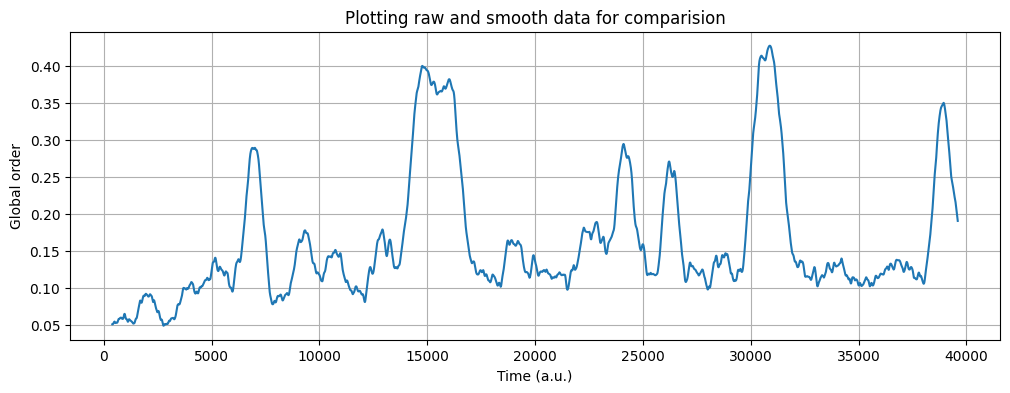

In [140]:
dt=0.05
#put  iteration number for which you want to plot
df_smooth=df_itr['5'].rolling(window=800, center=True).mean()

#defining time and timesteps for data
time_steps = list(range(0,df_smooth.shape[0]))   
time=np.multiply(time_steps,dt)

#plot the iteration to see transitions
#To plot comparision, uncomment
f = plt.figure(figsize=(12, 4))
plt.title("Plotting raw and smooth data for comparision") 

sync_smooth = df_smooth

plt.plot(time_steps,sync_smooth)
plt.ylabel("Global order")
plt.xlabel("Time (a.u.)")
#plt.axvline(16668)
#plt.axvline(14008)
#plt.axvline(31644)
#plt.axvline(29967)

plt.grid(True)
plt.show()

In [46]:
d1=36000-15000
d2=31644-29967
m=d1*0.05
print(m)

1050.0


In [25]:
(d1+d2)*0.05

216.85000000000002

In [13]:
df_itr['5'].to_csv('check_st.csv')

In [12]:
a=df_smooth[df_smooth>0.1]
b=df_smooth[df_smooth<0.11]
# Find the intersection
intersection = pd.merge(a, b, how='inner')

print(intersection)


             5
0     0.100020
1     0.100095
2     0.100164
3     0.100228
4     0.100288
...        ...
2819  0.109146
2820  0.109313
2821  0.109484
2822  0.109660
2823  0.109841

[2824 rows x 1 columns]


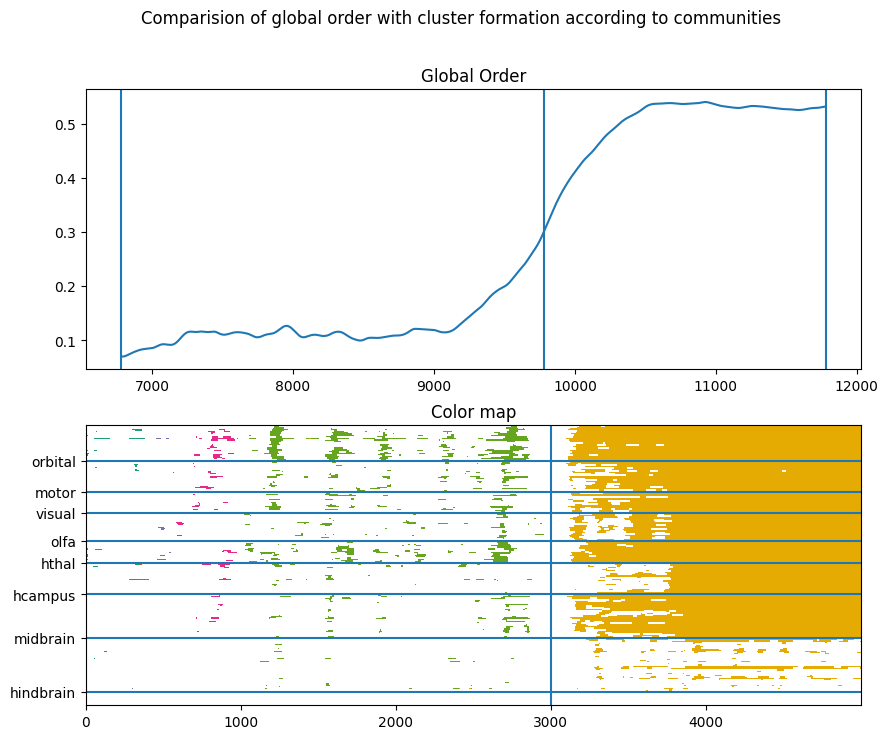

In [87]:
fig, axs = plt.subplots(3, 1, figsize=(10, 8))
label_in=[]
axs[0].plot(time_steps[6780:9780+2000],sync_smooth[6780:9780+2000])
axs[0].set_title('Global Order')
axs[0].axvline(9780)
axs[0].axvline(6780)
axs[0].axvline(9780+2000)
axs[1].imshow(rearranged_matrix.T,cmap='Dark2',aspect='auto')
for _i in np.cumsum([len(v) for v in _x.values()]): 
    label_in.append(_i)
    axs[1].axhline(_i)
axs[1].axvline(3000)
label=['motor','visual','orbital','hthal','olfa','hcampus','midbrain','hindbrain']

axs[1].set_yticks(label_in)
axs[1].set_yticklabels(label)

#fig.colorbar(cax1, ax=axs[1])
#colorbar=plt.colorbar()
axs[1].set_title('Color map')
plt.suptitle('Comparision of global order with cluster formation according to communities')
plt.savefig('compa_3_threshold')

In [139]:
df_nc.head()

0    1    2    3    4    5    6    7    8    9    ...  416  417  418  \
1 0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
  1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
  2  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
  3  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
  4  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   

     419  420  421  422  423  424  425  
1 0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
  1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
  2  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
  3  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
  4  0.0  0.0  0.0  0.0  0.0  0.0  0.0  

[5 rows x 426 columns]

In [87]:

matrix=df_nc.loc[1].values
np.place(matrix,matrix==0,np.nan)
desired_order = [item for sublist in _x.values() for item in sublist]
rearranged_matrix = matrix[:, desired_order]
fig, axs = plt.subplots(8, 4, figsize=(10, 8))
label_in=[]
axs[0,1].plot(time_steps[6780:9780+2000],sync_smooth[6780:9780+2000])
axs[0,1].set_title('Global Order')
axs[0,1].axvline(9780)
axs[0,1].axvline(6780)
axs[0,1].axvline(9780+2000)
axs[1,1].imshow(rearranged_matrix.T,cmap='Dark2',aspect='auto')
for _i in np.cumsum([len(v) for v in _x.values()]): 
    label_in.append(_i)
    axs[1].axhline(_i)
axs[1].axvline(3000)
label=['motor','visual','orbital','hthal','olfa','hcampus','midbrain','hindbrain']

axs[1].set_yticks(label_in)
axs[1].set_yticklabels(label)

#fig.colorbar(cax1, ax=axs[1])
#colorbar=plt.colorbar()
axs[1].set_title('Color map')
plt.suptitle('Comparision of global order with cluster formation according to communities')
plt.savefig('compa_3_threshold')

NameError: name 'df_nc' is not defined

In [82]:
len(_x[1])

70

In [50]:
df_nc.loc[1].iloc[3000:]

,0,1,2,3,4,5,6,7,8,9,...,416,417,418,419,420,421,422,423,424,425
3000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0
3001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0
3002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0
3003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0
3004,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,3.0,0.0,0.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4996,3.0,0.0,0.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4997,3.0,0.0,0.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4998,3.0,0.0,0.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
